# install

In [ ]:
!pip install ultralytics ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git

In [ ]:
!pip install chromadb

In [ ]:
!pip install yt-dlp

# Import

In [39]:
import cv2
import numpy as np
import os
import scipy.io as sio
import shutil
from pathlib import Path
from scipy.io import loadmat
from PIL import Image
import zipfile
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm import tqdm

from ultralytics import YOLO
import torch
import clip

import chromadb
from chromadb.config import Settings

# Data

In [4]:
!mkdir -p /content/prw_dataset

In [5]:
import kagglehub

path = kagglehub.dataset_download("edoardomerli/prw-person-re-identification-in-the-wild")

print("Path to dataset files:", path)

100%|██████████| 2.67G/2.67G [00:20<00:00, 140MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/edoardomerli/prw-person-re-identification-in-the-wild/versions/1


In [6]:
def extract_kaggle_dataset(download_path, extract_to='/content/prw_dataset'):

    os.makedirs(extract_to, exist_ok=True)

    zip_files = []
    for root, dirs, files in os.walk(download_path):
        for file in files:
            if file.endswith('.zip'):
                zip_files.append(os.path.join(root, file))

    if not zip_files:
        print("No zip files found. Dataset might be already extracted.")
        # If no zip, just copy the contents
        !cp -r {download_path}/* {extract_to}/
        return extract_to

    print(f"Found {len(zip_files)} zip file(s)")

    # Extract each zip file
    for zip_path in zip_files:
        print(f"Extracting: {os.path.basename(zip_path)}")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            # Get total file count for progress bar
            file_list = zip_ref.namelist()

            for file in tqdm(file_list, desc=f"Extracting {os.path.basename(zip_path)}"):
                zip_ref.extract(file, extract_to)

    print(f"Dataset extracted to: {extract_to}")
    return extract_to

dataset_path = extract_kaggle_dataset(path)

No zip files found. Dataset might be already extracted.


### Data processing

In [43]:
IMAGE_DIR = "/content/prw_dataset/frames"
ANNOT_DIR = "/content/prw_dataset/annotations"
YOLO_LABEL_DIR = "/content/config/yolo_labels"

In [ ]:
os.makedirs(YOLO_LABEL_DIR, exist_ok=True)

In [ ]:
def mat_to_yolo(image_path, mat_path, output_txt_path, class_id=0):

  img = Image.open(image_path)
  width, height = img.size

  mat = loadmat(mat_path)

  if 'box_new' not in mat:
    return

  boxes = mat['box_new']

  yolo_lines = []

  for box in boxes:
    pid, x, y, w, h = box
    x_center = (x + w*0.5)/width
    y_center = (y + h*0.5)/height
    w_norm = w/width
    h_norm = h/height

    if w_norm <= 0 or h_norm <= 0:
      continue

    yolo_lines.append(
        f"{class_id} {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}"
    )

  with open(output_txt_path, "w") as f:
    f.write("\n".join(yolo_lines))

In [ ]:
from matplotlib import image
for file in os.listdir(IMAGE_DIR):
  if not file.lower().endswith((".jpg",".png")):
    continue

  img_name = os.path.splitext(file)[0]
  image_file = os.path.join(IMAGE_DIR, file)
  mat_file = os.path.join(ANNOT_DIR, f"{img_name}.jpg.mat")
  txt_file = os.path.join(YOLO_LABEL_DIR, f"{img_name}.txt")

  if not os.path.exists(mat_file):
    print("Skipped, no annotation:", mat_file)
    continue

  if 'box_new' not in loadmat(mat_file):
    print("Skipped, no boxes:", mat_file)
    continue

  mat_to_yolo(image_file, mat_file, txt_file)

print("Finished conversion to YOLO labels!")

Skipped, no boxes: /content/prw_dataset/annotations/c6s1_036851.jpg.mat
Skipped, no boxes: /content/prw_dataset/annotations/c1s3_054251.jpg.mat
Skipped, no boxes: /content/prw_dataset/annotations/c3s2_120269.jpg.mat
Skipped, no boxes: /content/prw_dataset/annotations/c3s2_067303.jpg.mat
Skipped, no boxes: /content/prw_dataset/annotations/c2s1_049776.jpg.mat
Skipped, no boxes: /content/prw_dataset/annotations/c6s2_112243.jpg.mat
Skipped, no boxes: /content/prw_dataset/annotations/c5s2_126174.jpg.mat
Skipped, no boxes: /content/prw_dataset/annotations/c3s2_116644.jpg.mat
Skipped, no boxes: /content/prw_dataset/annotations/c5s2_028755.jpg.mat
Skipped, no boxes: /content/prw_dataset/annotations/c2s2_104957.jpg.mat
Skipped, no boxes: /content/prw_dataset/annotations/c6s2_051218.jpg.mat
Skipped, no boxes: /content/prw_dataset/annotations/c3s2_067378.jpg.mat
Skipped, no boxes: /content/prw_dataset/annotations/c2s2_122227.jpg.mat
Skipped, no boxes: /content/prw_dataset/annotations/c1s3_032101.

In [44]:
anno_files = os.listdir(ANNOT_DIR)
root = "/content/prw_dataset"

In [45]:
output_dir = "/content/config/prw_yolo_split/"

# Create YOLO-style folders
for split in ['train', 'test']:
    os.makedirs(f"{output_dir}/images/{split}", exist_ok=True)
    os.makedirs(f"{output_dir}/labels/{split}", exist_ok=True)

# Load train and test frame names
train_mat = sio.loadmat(os.path.join(root, 'frame_train.mat'))
test_mat = sio.loadmat(os.path.join(root, 'frame_test.mat'))

# Extract frame names
train_frames = [f[0][0] for f in train_mat['img_index_train']]
test_frames = [f[0][0] for f in test_mat['img_index_test']]

# Copy images and labels for train
for frame in train_frames:
    # image file
    frame = frame + ".jpg"
    src_img = os.path.join(IMAGE_DIR, frame)
    dst_img = f"{output_dir}/images/train/{frame}"
    if os.path.exists(src_img):
        shutil.copy(src_img, dst_img)
    # label file
    label_name = frame.replace('.jpg', '.txt')
    src_lbl = os.path.join(YOLO_LABEL_DIR, label_name)
    dst_lbl = f"{output_dir}/labels/train/{label_name}"
    if os.path.exists(src_lbl):
        shutil.copy(src_lbl, dst_lbl)

# for test
for frame in test_frames:
    frame = frame + ".jpg"
    src_img = os.path.join(IMAGE_DIR, frame)
    dst_img = f"{output_dir}/images/test/{frame}"
    if os.path.exists(src_img):
        shutil.copy(src_img, dst_img)
    label_name = frame.replace('.jpg', '.txt')
    src_lbl = os.path.join(YOLO_LABEL_DIR, label_name)
    dst_lbl = f"{output_dir}/labels/test/{label_name}"
    if os.path.exists(src_lbl):
        shutil.copy(src_lbl, dst_lbl)

print("Train/test split completed.")

Train/test split completed.


# Model

### Model setup

In [ ]:
import yaml


data_config = {
    'path': output_dir,
    'train': 'images/train',
    'val': 'images/test',
    'test': 'images/test',
    'nc': 1,
    'names': ['person']
}

with open('prw.yaml', 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print("prw.yaml created successfully.")

prw.yaml created successfully.


In [ ]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 51.8/112.6 GB disk)


In [ ]:
model = YOLO('yolov8n.pt')

### training

In [ ]:
model.train(
    data='prw.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    workers=4,
    project='prw_detector',
    name='yolov8n_prw'
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=prw.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_prw3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bc575122210>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

### saving

In [ ]:
import shutil
import os

folder_to_zip = '/content/runs'

output_filename = 'run_yolo_checkpoint'

shutil.make_archive(output_filename, 'zip', folder_to_zip)

print(f"Created {output_filename}.zip")

Created run_yolo_checkpoint.zip


### loading

In [12]:
!unzip /content/run_yolo_checkpoint.zip

Archive:  /content/run_yolo_checkpoint.zip
   creating: detect/
   creating: detect/prw_detector/
   creating: detect/prw_detector/yolov8n_prw/
   creating: detect/prw_detector/yolov8n_prw2/
   creating: detect/prw_detector/yolov8n_prw3/
   creating: detect/prw_detector/yolov8n_prw/weights/
  inflating: detect/prw_detector/yolov8n_prw/args.yaml  
   creating: detect/prw_detector/yolov8n_prw3/weights/
  inflating: detect/prw_detector/yolov8n_prw3/confusion_matrix_normalized.png  
  inflating: detect/prw_detector/yolov8n_prw3/confusion_matrix.png  
  inflating: detect/prw_detector/yolov8n_prw3/train_batch14280.jpg  
  inflating: detect/prw_detector/yolov8n_prw3/train_batch14282.jpg  
  inflating: detect/prw_detector/yolov8n_prw3/labels.jpg  
  inflating: detect/prw_detector/yolov8n_prw3/results.csv  
  inflating: detect/prw_detector/yolov8n_prw3/BoxP_curve.png  
  inflating: detect/prw_detector/yolov8n_prw3/train_batch2.jpg  
  inflating: detect/prw_detector/yolov8n_prw3/BoxPR_curve.png 

In [13]:
# Load YOLO model
yolo_model = YOLO('/content/detect/prw_detector/yolov8n_prw3/weights/best.pt')

# Load CLIP model
device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model, preprocess = clip.load("ViT-B/32", device=device)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 147MiB/s]


In [14]:

# Get list of test image names
import scipy.io as sio
test_mat = sio.loadmat("/content/prw_dataset/frame_test.mat")
test_frames = [f[0][0] + ".jpg" for f in test_mat['img_index_test']]

print(f"Number of test images: {len(test_frames)}")

Number of test images: 6112


# vector embeddings

In [15]:
embeddings = []
metadata = []

conf_thresh = 0.5

for img_name in tqdm(test_frames, desc="Processing images"):
    img_path = os.path.join(IMAGE_DIR, img_name)
    if not os.path.exists(img_path):
        continue

    # Read image
    img = cv2.imread(img_path)
    if img is None:
        continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Run YOLO detection
    results = yolo_model(img_rgb, verbose=False)[0]

    for box in results.boxes:
        conf = box.conf.item()
        if conf < conf_thresh:
            continue

        # Get bounding box coordinates (x1, y1, x2, y2)
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())

        # Crop the person
        crop = img_rgb[y1:y2, x1:x2]
        if crop.size == 0:
            continue

        # Convert crop to PIL and apply CLIP preprocessing
        crop_pil = Image.fromarray(crop)
        image_tensor = preprocess(crop_pil).unsqueeze(0).to(device)

        # Generate embedding
        with torch.no_grad():
            emb = clip_model.encode_image(image_tensor).cpu().numpy().flatten()

        embeddings.append(emb)

        # Save metadata
        metadata.append({
            'frame': img_name,
            'bbox': [x1, y1, x2, y2],
            'confidence': conf,
            'camera': img_name.split('_')[0]   # e.g., 'c1s1'
        })

print(f"Total detected persons: {len(embeddings)}")

Processing images: 100%|██████████| 6112/6112 [08:11<00:00, 12.44it/s]

Total detected persons: 19309


In [16]:
client = chromadb.Client(Settings(anonymized_telemetry=False))


collection = client.create_collection(
    name="prw_people",
    metadata={"hnsw:space": "cosine"}
)

In [18]:
ids = [f"person_{i:06d}" for i in range(len(embeddings))]
metadatas = metadata

### batching

In [20]:
batch_size = 5000   # safe below 5461
total = len(ids)

for i in range(0, total, batch_size):
    batch_ids = ids[i:i+batch_size]
    batch_embeddings = embeddings[i:i+batch_size]
    batch_metadatas = metadatas[i:i+batch_size]

    collection.add(
        ids=batch_ids,
        embeddings=batch_embeddings,
        metadatas=batch_metadatas
    )
    print(f"Added batch {i//batch_size + 1}/{(total-1)//batch_size + 1}")

print(f"Total items in collection: {collection.count()}")

Added batch 1/4
Added batch 2/4
Added batch 3/4
Added batch 4/4
Total items in collection: 19309


# Similarity Search

In [21]:
def chroma_search(query_text, top_k=5):
    # Encode the query using CLIP
    with torch.no_grad():
        text_tokens = clip.tokenize([query_text]).to(device)
        query_emb = clip_model.encode_text(text_tokens).cpu().numpy().flatten().tolist()

    # Query Chroma
    results = collection.query(
        query_embeddings=[query_emb],
        n_results=top_k,
        include=["metadatas", "distances"]
    )

    return results

1: c1s3_029601.jpg (bbox [474, 473, 784, 1069]) distance 0.673
2: c5s2_119324.jpg (bbox [465, 352, 563, 570]) distance 0.674
3: c2s2_016487.jpg (bbox [1660, 596, 1853, 1074]) distance 0.677
4: c5s2_119424.jpg (bbox [466, 356, 564, 571]) distance 0.679
5: c5s2_119399.jpg (bbox [29, 393, 240, 805]) distance 0.680


In [ ]:
query = "person wearing a red jacket"
results = chroma_search(query, top_k=5)

for i, (dist, meta) in enumerate(zip(results['distances'][0], results['metadatas'][0])):
    print(f"{i+1}: {meta['frame']} (bbox {meta['bbox']}) distance {dist:.3f}")

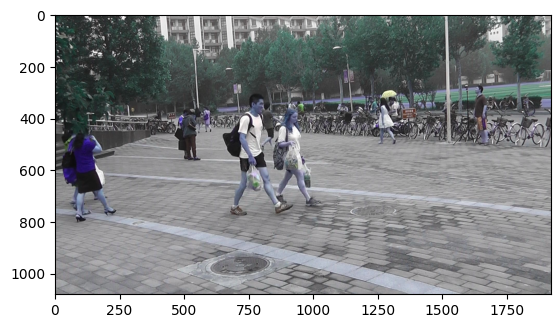

In [27]:
for x in results['metadatas'][0]:
  frame = x['frame']
  img = cv2.imread(f"/content/prw_dataset/frames/{frame}")
  # bbox = [x1, y1, w, h]

  plt.imshow(img)

# Quering with Images

In [28]:
def display_query_results(query_text, top_k=5, image_dir="/content/prw_dataset/frames"):

    # Encode the text query using CLIP
    with torch.no_grad():
        text_tokens = clip.tokenize([query_text]).to(device)
        query_emb = clip_model.encode_text(text_tokens).cpu().numpy().flatten().tolist()

    # Query Chroma
    results = collection.query(
        query_embeddings=[query_emb],
        n_results=top_k,
        include=["metadatas", "distances"]
    )


    ids = results['ids'][0]
    distances = results['distances'][0]
    metadatas = results['metadatas'][0]

    # Convert distances to similarity scores
    similarities = [1 - d for d in distances]

    # Set up plot
    fig, axes = plt.subplots(1, top_k, figsize=(5*top_k, 5))
    if top_k == 1:
        axes = [axes]

    for i, (meta, sim, dist) in enumerate(zip(metadatas, similarities, distances)):
        frame_file = meta['frame']
        img_path = os.path.join(IMAGE_DIR, frame_file)

        # Load image
        img = Image.open(img_path).convert("RGB")

        # Draw bounding box
        x1, y1, x2, y2 = meta['bbox']   # [x1, y1, x2, y2]
        ax = axes[i]
        ax.imshow(img)
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor='red', facecolor='none'
        )
        ax.add_patch(rect)
        ax.set_title(f"Sim: {sim:.3f} (dist: {dist:.3f})\n{frame_file}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

    # Print details
    for i, meta in enumerate(metadatas):
        print(f"{i+1}: {meta['frame']} | bbox {meta['bbox']} | confidence {meta.get('confidence', 'N/A'):.3f} | camera {meta['camera']}")

    return results

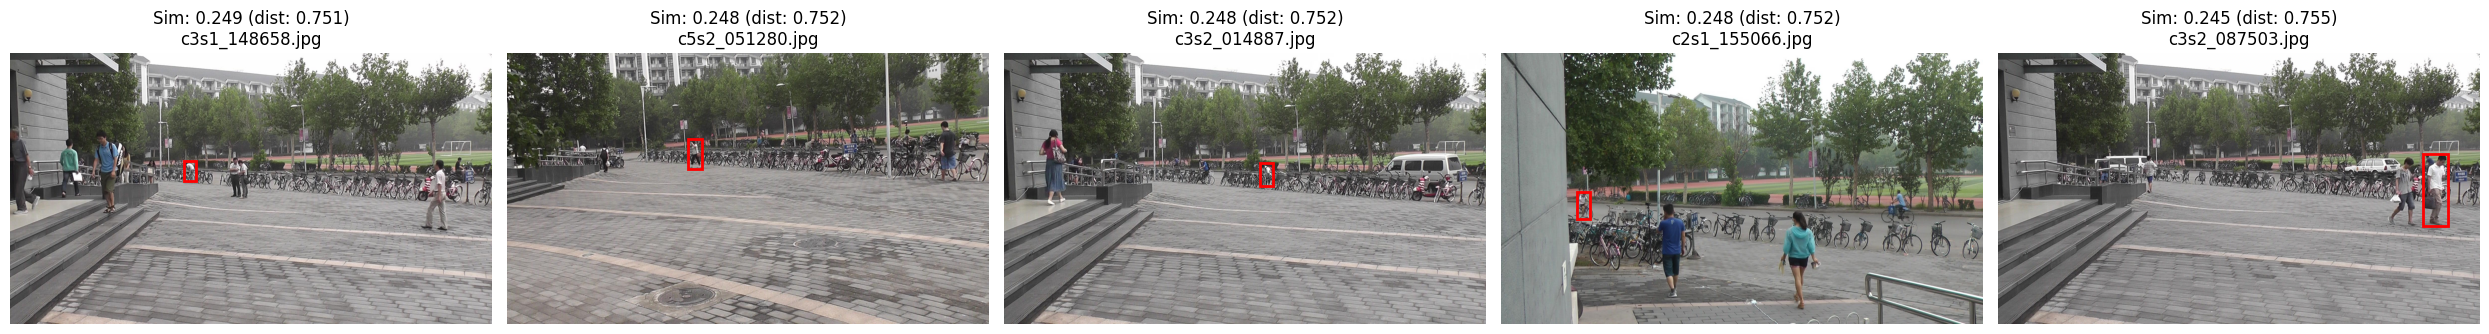

1: c3s1_148658.jpg | bbox [691, 431, 739, 511] | confidence 0.569 | camera c3s1
2: c5s2_051280.jpg | bbox [722, 343, 777, 462] | confidence 0.573 | camera c5s2
3: c3s2_014887.jpg | bbox [1021, 439, 1073, 530] | confidence 0.585 | camera c3s2
4: c2s1_155066.jpg | bbox [301, 552, 355, 661] | confidence 0.547 | camera c2s1
5: c3s2_087503.jpg | bbox [1692, 403, 1792, 691] | confidence 0.822 | camera c3s2


{'ids': [['person_005403',
   'person_013703',
   'person_006162',
   'person_003210',
   'person_008874']],
 'embeddings': None,
 'documents': None,
 'uris': None,
 'included': ['metadatas', 'distances'],
 'data': None,
 'metadatas': [[{'frame': 'c3s1_148658.jpg',
    'confidence': 0.5689891576766968,
    'bbox': [691, 431, 739, 511],
    'camera': 'c3s1'},
   {'frame': 'c5s2_051280.jpg',
    'confidence': 0.5731094479560852,
    'bbox': [722, 343, 777, 462],
    'camera': 'c5s2'},
   {'camera': 'c3s2',
    'confidence': 0.5854331851005554,
    'bbox': [1021, 439, 1073, 530],
    'frame': 'c3s2_014887.jpg'},
   {'camera': 'c2s1',
    'confidence': 0.5472102165222168,
    'frame': 'c2s1_155066.jpg',
    'bbox': [301, 552, 355, 661]},
   {'frame': 'c3s2_087503.jpg',
    'bbox': [1692, 403, 1792, 691],
    'confidence': 0.8222940564155579,
    'camera': 'c3s2'}]],
 'distances': [[0.7511500120162964,
   0.7517102360725403,
   0.7518723607063293,
   0.7520703673362732,
   0.754680275917053

In [29]:
display_query_results("cycles", top_k=5)

# Video Processing

In [30]:
def process_video(video_path, collection_name, frame_skip=30, conf_thresh=0.5):
    # Create or get collection
    collection = client.get_or_create_collection(
        name=collection_name,
        metadata={"hnsw:space": "cosine"}
    )

    # Open video
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"Video: {video_path}, FPS: {fps:.2f}, Total frames: {total_frames}")

    frame_idx = 0
    added_count = 0
    batch_ids = []
    batch_embeddings = []
    batch_metadatas = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Skip frames
        if frame_idx % frame_skip != 0:
            frame_idx += 1
            continue

        # Convert BGR to RGB
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # Run YOLO detection
        results = yolo_model(frame_rgb, verbose=False)[0]

        for box in results.boxes:
            conf = box.conf.item()
            if conf < conf_thresh:
                continue

            # Get bbox
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
            crop = frame_rgb[y1:y2, x1:x2]
            if crop.size == 0:
                continue

            # Prepare crop for CLIP
            crop_pil = Image.fromarray(crop)
            image_tensor = preprocess(crop_pil).unsqueeze(0).to(device)

            # Generate embedding
            with torch.no_grad():
                emb = clip_model.encode_image(image_tensor).cpu().numpy().flatten().tolist()

            # Metadata
            metadata = {
                "video_path": video_path,
                "frame_index": frame_idx,
                "timestamp": frame_idx / fps,
                "bbox": [x1, y1, x2, y2],
                "confidence": conf
            }

            # Unique ID
            person_id = f"{collection_name}_frame{frame_idx:06d}_box{len(batch_ids):03d}"

            batch_ids.append(person_id)
            batch_embeddings.append(emb)
            batch_metadatas.append(metadata)
            added_count += 1

        # Add in batches to avoid Chroma batch size limit
        if len(batch_ids) >= 5000:
            collection.add(
                ids=batch_ids,
                embeddings=batch_embeddings,
                metadatas=batch_metadatas
            )
            print(f"Added batch of {len(batch_ids)} embeddings. Total so far: {added_count}")
            batch_ids, batch_embeddings, batch_metadatas = [], [], []

        frame_idx += 1

    # Add any remaining
    if batch_ids:
        collection.add(
            ids=batch_ids,
            embeddings=batch_embeddings,
            metadatas=batch_metadatas
        )
        print(f"Added final batch of {len(batch_ids)} embeddings.")

    cap.release()
    print(f"Processing complete. Total persons added: {added_count}")
    return collection

### query video

In [31]:
def query_video(collection_name, query_text, top_k=5):

    collection = client.get_collection(collection_name)

    # Encode query
    with torch.no_grad():
        text_tokens = clip.tokenize([query_text]).to(device)
        query_emb = clip_model.encode_text(text_tokens).cpu().numpy().flatten().tolist()

    # Query Chroma
    results = collection.query(
        query_embeddings=[query_emb],
        n_results=top_k,
        include=["metadatas", "distances"]
    )

    metadatas = results['metadatas'][0]
    distances = results['distances'][0]
    similarities = [1 - d for d in distances]

    # Prepare plot
    fig, axes = plt.subplots(1, top_k, figsize=(5*top_k, 5))
    if top_k == 1:
        axes = [axes]

    for i, (meta, sim, dist) in enumerate(zip(metadatas, similarities, distances)):
        video_path = meta['video_path']
        frame_idx = meta['frame_index']
        bbox = meta['bbox']
        conf = meta['confidence']

        # Read the specific frame from video
        cap = cv2.VideoCapture(video_path)
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        cap.release()
        if not ret:
            print(f"Warning: Could not read frame {frame_idx} from {video_path}")
            continue

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        ax = axes[i]
        ax.imshow(frame_rgb)
        rect = patches.Rectangle(
            (bbox[0], bbox[1]), bbox[2]-bbox[0], bbox[3]-bbox[1],
            linewidth=2, edgecolor='red', facecolor='none'
        )
        ax.add_patch(rect)
        ax.set_title(f"Sim: {sim:.3f} (dist: {dist:.3f})\nFrame {frame_idx}, conf {conf:.2f}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

    # Print details
    for i, meta in enumerate(metadatas):
        print(f"{i+1}: Frame {meta['frame_index']} | bbox {meta['bbox']} | confidence {meta['confidence']:.3f} | timestamp {meta['timestamp']:.2f}s")

# loading from net

In [32]:
import urllib.request

In [33]:
url = "https://www.youtube.com/watch?v=YzcawvDGe4Y"
output_path = "/content/video.mp4"
urllib.request.urlretrieve(url, output_path)

('/content/video.mp4', <http.client.HTTPMessage at 0x7a5a6a524f80>)

In [35]:
import yt_dlp

url = "https://www.youtube.com/watch?v=YzcawvDGe4Y"
output_path = "/content/video.mp4"

ydl_opts = {
    'outtmpl': output_path,   # output template
    'format': 'best',         # best quality
}
with yt_dlp.YoutubeDL(ydl_opts) as ydl:
    ydl.download([url])

print("YouTube video downloaded!")

[youtube] Extracting URL: https://www.youtube.com/watch?v=YzcawvDGe4Y
[youtube] YzcawvDGe4Y: Downloading webpage


[youtube] YzcawvDGe4Y: Downloading android vr player API JSON
[info] YzcawvDGe4Y: Downloading 1 format(s): 18
[download] Destination: /content/video.mp4
[download] 100% of    9.08MiB in 00:00:00 at 9.89MiB/s   
YouTube video downloaded!


Video: /content/video.mp4, FPS: 29.97, Total frames: 3493
Added final batch of 624 embeddings.
Processing complete. Total persons added: 624


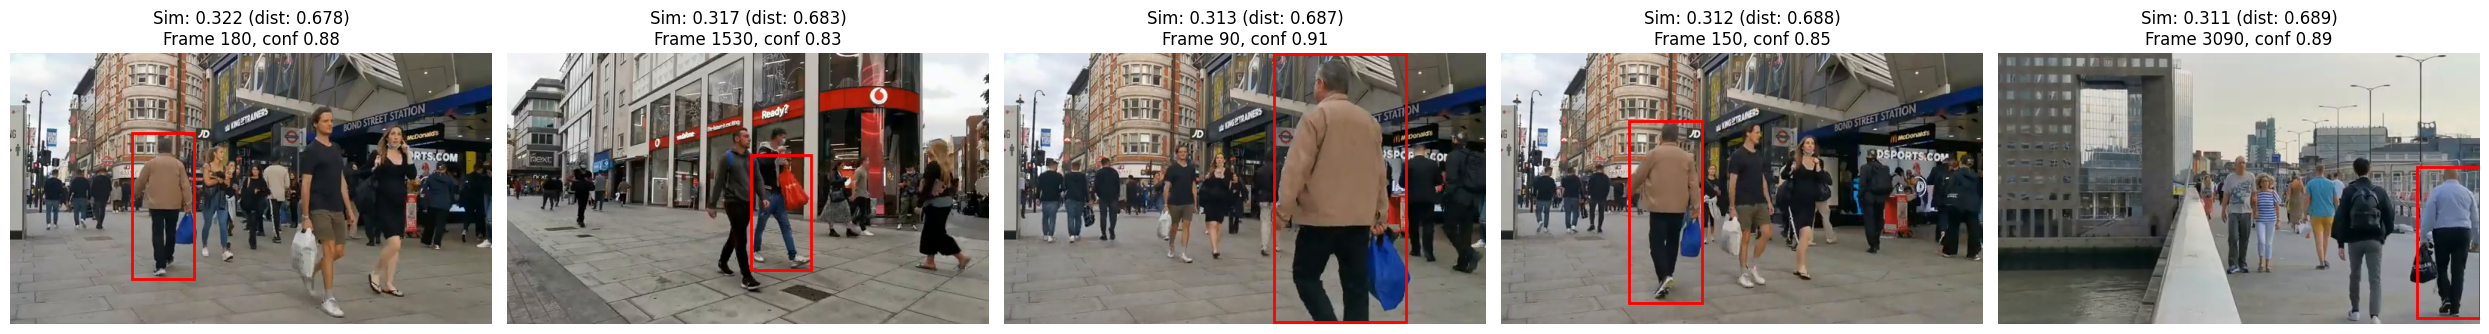

1: Frame 180 | bbox [162, 106, 244, 300] | confidence 0.882 | timestamp 6.01s
2: Frame 1530 | bbox [324, 135, 403, 288] | confidence 0.828 | timestamp 51.05s
3: Frame 90 | bbox [358, 1, 533, 357] | confidence 0.906 | timestamp 3.00s
4: Frame 150 | bbox [169, 90, 267, 331] | confidence 0.853 | timestamp 5.00s
5: Frame 3090 | bbox [556, 151, 639, 352] | confidence 0.892 | timestamp 103.10s


In [37]:
# Process a video (adjust paths)
video_path = output_path
collection_name = "street_view"

process_video(video_path, collection_name, frame_skip=30, conf_thresh=0.5)

# Query
query_video(collection_name, "person with blue bag", top_k=5)